   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB
None


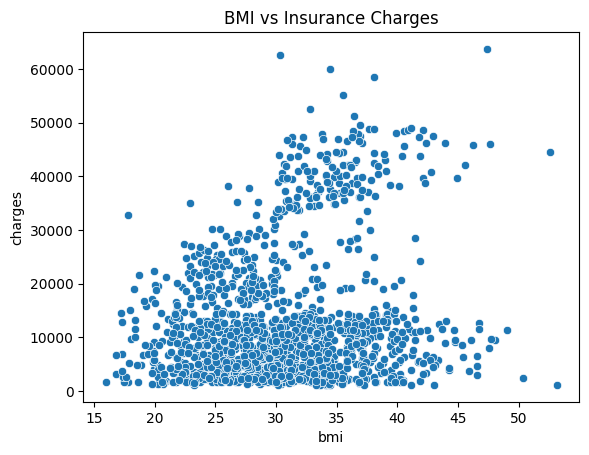

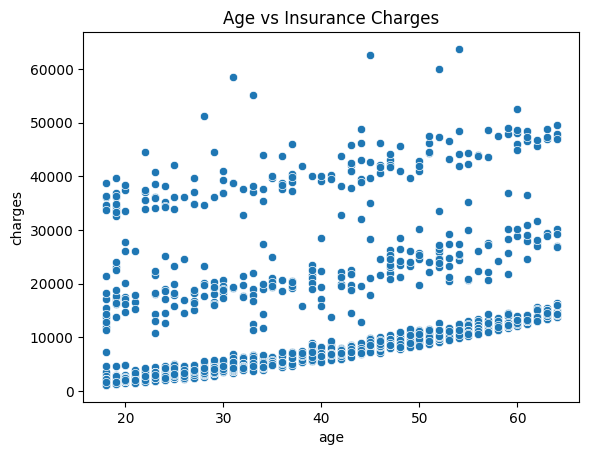

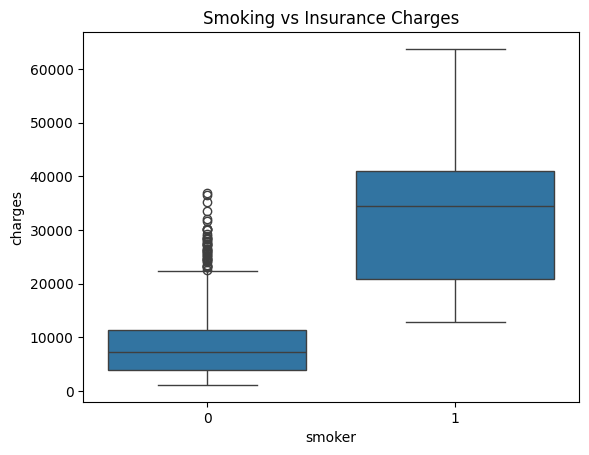

MAE: 4181.194473753645
RMSE: 5796.284659276271


In [1]:
# ==========================================
# Name: Faiza Memon
# TASK 4: INSURANCE CLAIM PREDICTION
# DevelopersHub Internship
# ==========================================

# ---------------- IMPORT LIBRARIES ----------------
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

# ---------------- LOAD DATASET ----------------
df = pd.read_csv("insurance.csv")

print(df.head())
print(df.info())

# ---------------- ENCODING ----------------
df['sex'] = df['sex'].map({'male': 0, 'female': 1})
df['smoker'] = df['smoker'].map({'no': 0, 'yes': 1})
df = pd.get_dummies(df, columns=['region'], drop_first=True)

# ---------------- EDA VISUALIZATION ----------------

# BMI vs Charges
plt.figure()
sns.scatterplot(x='bmi', y='charges', data=df)
plt.title("BMI vs Insurance Charges")
plt.show()

# Age vs Charges
plt.figure()
sns.scatterplot(x='age', y='charges', data=df)
plt.title("Age vs Insurance Charges")
plt.show()

# Smoker impact
plt.figure()
sns.boxplot(x='smoker', y='charges', data=df)
plt.title("Smoking vs Insurance Charges")
plt.show()

# ---------------- SPLIT DATA ----------------
X = df.drop('charges', axis=1)
y = df['charges']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ---------------- MODEL TRAINING ----------------
model = LinearRegression()
model.fit(X_train, y_train)

# ---------------- PREDICTION ----------------
y_pred = model.predict(X_test)

# ---------------- EVALUATION ----------------
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("MAE:", mae)
print("RMSE:", rmse)